Last update:
* Batch-2007-Online-French
* May 2025

# Algebra & Calculus

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Recap `NumPy`

In [2]:
A = np.array([[1, 2],
              [3, 4],
              [5, 6],])

In [3]:
A

array([[1, 2],
       [3, 4],
       [5, 6]])

##### `type`, `shape`, `size`, `ndim`, `dtype`

In [4]:
type(A)

numpy.ndarray

In [5]:
A.shape

(3, 2)

In [6]:
A.size

6

In [7]:
A.ndim

2

In [8]:
A.dtype

dtype('int64')

##### `indexing`

In [9]:
A

array([[1, 2],
       [3, 4],
       [5, 6]])

***Select specific elements***

In [10]:
A[1,1]

np.int64(4)

In [11]:
A[2,1]

np.int64(6)

In [12]:
A[2,0]

np.int64(5)

In [13]:
A[-1,0]

np.int64(5)

#### `slicing`

In [14]:
# first row
A[0]

array([1, 2])

In [15]:
# alternatively
A[0,:]

array([1, 2])

In [16]:
# second row
A[1]

array([3, 4])

In [17]:
#alternatively
A[1,:]

array([3, 4])

In [18]:
# third row
A[2]

array([5, 6])

In [20]:
# There is no 4th row
# A[3]

In [21]:
# last row
A[-1]

array([5, 6])

In [22]:
# penultimate row
A[-2]

array([3, 4])

In [23]:
A

array([[1, 2],
       [3, 4],
       [5, 6]])

In [24]:
# first column
A[:,0]

array([1, 3, 5])

In [25]:
# second column
A[:,1]

array([2, 4, 6])

#### `boolean indexing`

In [26]:
A

array([[1, 2],
       [3, 4],
       [5, 6]])

In [27]:
## This is a boolean mask
boolean_mask = A > 4
boolean_mask

array([[False, False],
       [False, False],
       [ True,  True]])

In [28]:
A[boolean_mask]

array([5, 6])

How do we use boolean masks with DataFrames ?

In [29]:
import seaborn as sns

In [30]:
penguins = sns.load_dataset("penguins")
penguins.head(3)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female


In [31]:
penguins.shape

(344, 7)

In [32]:
penguins["species"].value_counts()

,count
species,
Adelie,152
Gentoo,124
Chinstrap,68


In [33]:
penguins["species"].value_counts(normalize=True)

,proportion
species,
Adelie,0.441860
Gentoo,0.360465
Chinstrap,0.197674


In [34]:
mask_for_gentoos = penguins["species"] == "Gentoo"
mask_for_gentoos

,species
0,False
1,False
2,False
3,False
4,False
...,...
339,True
340,True
341,True
342,True


In [35]:
penguins[mask_for_gentoos]

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
220,Gentoo,Biscoe,46.1,13.2,211.0,4500.0,Female
221,Gentoo,Biscoe,50.0,16.3,230.0,5700.0,Male
222,Gentoo,Biscoe,48.7,14.1,210.0,4450.0,Female
223,Gentoo,Biscoe,50.0,15.2,218.0,5700.0,Male
224,Gentoo,Biscoe,47.6,14.5,215.0,5400.0,Male
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


## 1. Algebra

In [36]:
2**3

8

In [37]:
A

array([[1, 2],
       [3, 4],
       [5, 6]])

In [38]:
A**3

array([[  1,   8],
       [ 27,  64],
       [125, 216]])

### 1.1) Functions

#### Define function `square_plus_one`

In [39]:
def square_plus_one(x):
    return x**2 + 1

In [40]:
square_plus_one(2)

5

In [41]:
square_plus_one(-2)

5

In [42]:
# with the lambda keyword
square_plus_one = lambda x: x**2 +1

In [43]:
square_plus_one(3)

10

#### Test `square_plus_one`

In [44]:
%%time
y = []
for x in range(1_000_000):
  y_temp = square_plus_one(x)
  y.append(y_temp)

CPU times: user 461 ms, sys: 35.8 ms, total: 496 ms
Wall time: 1.27 s


In [45]:
%%time
x = np.arange(1_000_000)
y = square_plus_one(x)

CPU times: user 3.61 ms, sys: 4.95 ms, total: 8.56 ms
Wall time: 17.2 ms


#### Plot `square_plus_one` with `matplotlib.pyplot`

**`linspace`**

Values of x
[-5.         -3.88888889 -2.77777778 -1.66666667 -0.55555556  0.55555556
  1.66666667  2.77777778  3.88888889  5.        ]
Values of y
[26.         16.12345679  8.71604938  3.77777778  1.30864198  1.30864198
  3.77777778  8.71604938 16.12345679 26.        ]


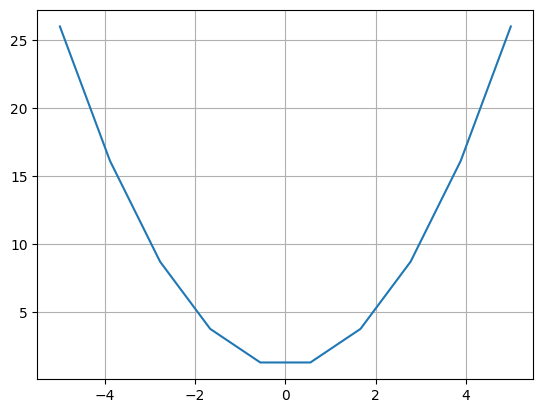

In [46]:
x = np.linspace(-5,5,10)
print("Values of x")
print(x)
y = square_plus_one(x)
print("Values of y")
print(y)

plt.plot(x,y)
plt.grid()
plt.show()

In [47]:
x.shape

(10,)

In [48]:
y.shape

(10,)

**`arange`**

Values of x
[-5.  -4.5 -4.  -3.5 -3.  -2.5 -2.  -1.5 -1.  -0.5  0.   0.5  1.   1.5
  2.   2.5  3.   3.5  4.   4.5]
Values of y
[26.   21.25 17.   13.25 10.    7.25  5.    3.25  2.    1.25  1.    1.25
  2.    3.25  5.    7.25 10.   13.25 17.   21.25]


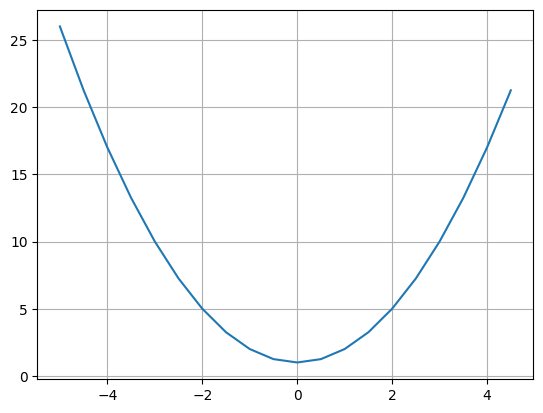

In [49]:
x = np.arange(-5,5,0.5)
print("Values of x")
print(x)
y = square_plus_one(x)
print("Values of y")
print(y)

plt.plot(x,y)
plt.grid()
plt.show()

#### Plot a multivariate function with `plotly`

**💡 Use shortcuts 👉 on Mac: drag with `Ctrl` (=Pan), `Option` (=Zoom) or `Cmd` (=Rotate)**

In [50]:
def myfunction(x,y):
  return 2*x-3*y+7

In [51]:
x , y = np.meshgrid(range(10), range(10))
z = myfunction (x,y)

In [52]:
import plotly.graph_objects as go

fig = go.Figure(go.Surface(x=x,
                           y=y,
                           z=z))
fig.show()

### 1.2) Equations

### 1.3) Vectors

In [53]:
u = np.array([1, 2, 3])

print(u.shape)
u

(3,)


array([1, 2, 3])

In [54]:
u_row = np.expand_dims(u, axis = 0)
print(u_row.shape)
u_row

(1, 3)


array([[1, 2, 3]])

In [55]:
u_row = np.array([[1, 2, 3]])

print(u_row.shape )
u_row

(1, 3)


array([[1, 2, 3]])

In [56]:
u_column = np.array([[1],
                     [2],
                     [3]])

print(u_column.shape )
u_column

(3, 1)


array([[1],
       [2],
       [3]])

In [57]:
a = np.array([[1, 2, 3]])
b = np.array([[4, 5, 6, 7]])

In [58]:
a + b

ValueError: operands could not be broadcast together with shapes (1,3) (1,4) 

In [59]:
10*a

array([[10, 20, 30]])

#### Compute a `euclidean (L2) distance` in a 4D space


In [60]:
a = np.array([1, 2, 3, 4])

b = np.array([5, 5, 5, 5])

$AB = ||\boldsymbol b - \boldsymbol a||_2 = \sqrt{\color {red}{(b_1 - a_1)}^2
+ \color {teal}{(b_2 - a_2)}^2 \;+ \;... \;+ \;\color {orange}{(b_n - a_n)}^2} = \sqrt{\sum_{i=1}^{n} (b_i - a_i)^2}$

In [61]:
np.sqrt(np.sum((b-a)**2))

np.float64(5.477225575051661)

#### 🔥 Dot product Vector • Vector 🔥

In [62]:
a = np.array([1, 2, 3, 4])

b = np.array([5, 5, 5, 5])

In [63]:
1*5 + 2*5 + 3*5 + 4 *5

50

In [64]:
np.dot(a,b)

np.int64(50)

In [65]:
a.dot(b)

np.int64(50)

In [66]:
a @ b

np.int64(50)

### 1.4) Matrices

In [67]:
A = np.array([[1, 2, 3],
              [0, 1, 2]])

v = np.array([[4],
              [5],
              [6]])

B = np.array([[4, 1, -1, 0],
              [5, 0, 3, 2],
              [6, 4, 0, 1]])

In [68]:
A

array([[1, 2, 3],
       [0, 1, 2]])

In [69]:
A.shape

(2, 3)

In [70]:
A.T

array([[1, 0],
       [2, 1],
       [3, 2]])

In [71]:
A.T.shape

(3, 2)

In [72]:
A.T.T

array([[1, 2, 3],
       [0, 1, 2]])

#### 🔥🔥 Matrix • Vector 🔥🔥

In [73]:
A.shape, v.shape

((2, 3), (3, 1))

In [74]:
np.dot(A,v)

array([[32],
       [17]])

#### 🔥🔥🔥 Matrix • Matrix 🔥🔥🔥

In [75]:
A.shape, B.shape

((2, 3), (3, 4))

In [76]:
np.dot(A,B)

array([[32, 13,  5,  7],
       [17,  8,  3,  4]])

In [77]:
np.dot(A,B).shape

(2, 4)

#### 💥 Shape incompatibility 💥

In [78]:
A.shape, B.shape

((2, 3), (3, 4))

In [82]:
# np.dot(B,A)

In [83]:
np.eye(2)

array([[1., 0.],
       [0., 1.]])

In [84]:
np.eye(3)

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

In [85]:
np.eye(5)

array([[1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 1.]])

### 1.5) Matrix multiplication 🤝 `data science`